# DATA 602 Project 1: Model Training and Fine-Tuning

## Setup

In [1]:
!python -m pip install -q scikit-learn sklearn_evaluation scipy pandas numpy pyarrow seaborn umap-learn

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Any
import warnings
import os
from scipy.stats import randint
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve, 
    precision_recall_curve
)
from sklearn_evaluation import plot
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer, QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
import umap

/home/ballen/miniconda3/envs/data-science/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configurations

In [3]:
sns.set_style('darkgrid')

In [4]:
warnings.filterwarnings('ignore')

In [5]:
os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning'

## Load Master Data (Clean)
Use master dataset that was cleaned as part of EDA deliverable.

In [6]:
# X = pd.read_parquet('../datasets/clean/master_data.parquet')
X = pd.read_csv('../datasets/clean/master_data.csv')
X.shape

(103594, 23)

In [7]:
X.head()

,GENDER,CUSTOMER_TYPE,AGE,TYPE_OF_TRAVEL,CLASS,FLIGHT_DISTANCE,INFLIGHT_WIFI_SERVICE,DEPARTURE_ARRIVAL_TIME_CONVENIENT,EASE_OF_ONLINE_BOOKING,GATE_LOCATION,...,INFLIGHT_ENTERTAINMENT,ON-BOARD_SERVICE,LEG_ROOM_SERVICE,BAGGAGE_HANDLING,CHECKIN_SERVICE,INFLIGHT_SERVICE,CLEANLINESS,DEPARTURE_DELAY_IN_MINUTES,ARRIVAL_DELAY_IN_MINUTES,SATISFACTION
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103594 entries, 0 to 103593
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   GENDER                             103594 non-null  object 
 1   CUSTOMER_TYPE                      103594 non-null  object 
 2   AGE                                103594 non-null  int64  
 3   TYPE_OF_TRAVEL                     103594 non-null  object 
 4   CLASS                              103594 non-null  object 
 5   FLIGHT_DISTANCE                    103594 non-null  int64  
 6   INFLIGHT_WIFI_SERVICE              103594 non-null  int64  
 7   DEPARTURE_ARRIVAL_TIME_CONVENIENT  103594 non-null  int64  
 8   EASE_OF_ONLINE_BOOKING             103594 non-null  int64  
 9   GATE_LOCATION                      103594 non-null  int64  
 10  FOOD_AND_DRINK                     103594 non-null  int64  
 11  ONLINE_BOARDING                    1035

In [9]:
# Verify there are no null values
X.isnull().sum()

GENDER                               0
CUSTOMER_TYPE                        0
AGE                                  0
TYPE_OF_TRAVEL                       0
CLASS                                0
FLIGHT_DISTANCE                      0
INFLIGHT_WIFI_SERVICE                0
DEPARTURE_ARRIVAL_TIME_CONVENIENT    0
EASE_OF_ONLINE_BOOKING               0
GATE_LOCATION                        0
FOOD_AND_DRINK                       0
ONLINE_BOARDING                      0
SEAT_COMFORT                         0
INFLIGHT_ENTERTAINMENT               0
ON-BOARD_SERVICE                     0
LEG_ROOM_SERVICE                     0
BAGGAGE_HANDLING                     0
CHECKIN_SERVICE                      0
INFLIGHT_SERVICE                     0
CLEANLINESS                          0
DEPARTURE_DELAY_IN_MINUTES           0
ARRIVAL_DELAY_IN_MINUTES             0
SATISFACTION                         0
dtype: int64

### Converting specified columns to suitable data types

In [10]:
category_columns = [
    'GENDER',
    'CUSTOMER_TYPE',
    'TYPE_OF_TRAVEL',
    'CLASS',
    'INFLIGHT_WIFI_SERVICE',
    'DEPARTURE_ARRIVAL_TIME_CONVENIENT',
    'EASE_OF_ONLINE_BOOKING',
    'GATE_LOCATION',
    'FOOD_AND_DRINK',
    'ONLINE_BOARDING',
    'INFLIGHT_ENTERTAINMENT',
    'ON-BOARD_SERVICE',
    'LEG_ROOM_SERVICE',
    'BAGGAGE_HANDLING',
    'CHECKIN_SERVICE',
    'INFLIGHT_SERVICE',
    'CLEANLINESS',
    'SATISFACTION'
]

X[category_columns] = X[category_columns].astype('category')

# Convert specified columns to int64
int64_columns = [
    'DEPARTURE_DELAY_IN_MINUTES',
    'FLIGHT_DISTANCE',
    'AGE'
]

X[int64_columns] = X[int64_columns].astype('int64')

# Check the data types
print(X.dtypes)

GENDER                               category
CUSTOMER_TYPE                        category
AGE                                     int64
TYPE_OF_TRAVEL                       category
CLASS                                category
FLIGHT_DISTANCE                         int64
INFLIGHT_WIFI_SERVICE                category
DEPARTURE_ARRIVAL_TIME_CONVENIENT    category
EASE_OF_ONLINE_BOOKING               category
GATE_LOCATION                        category
FOOD_AND_DRINK                       category
ONLINE_BOARDING                      category
SEAT_COMFORT                            int64
INFLIGHT_ENTERTAINMENT               category
ON-BOARD_SERVICE                     category
LEG_ROOM_SERVICE                     category
BAGGAGE_HANDLING                     category
CHECKIN_SERVICE                      category
INFLIGHT_SERVICE                     category
CLEANLINESS                          category
DEPARTURE_DELAY_IN_MINUTES              int64
ARRIVAL_DELAY_IN_MINUTES          

## Prepare the Data for Training

In [11]:
# Define target
target = 'SATISFACTION'

### Analyze Class Imbalance

In [12]:
label_counts = X[target].value_counts()
pd.DataFrame({'counts': label_counts, 'ratio': label_counts / len(X)})

,counts,ratio
SATISFACTION,,
neutral or dissatisfied,58697,0.566606
satisfied,44897,0.433394


There is a slight class imbalance favoring `neutral or dissatisfied` as the majority and `satisfied` as the minority. We can relieve this imbalance by upsampling the minority class.

### Apply Upsampling to Minority Class

In [13]:
def apply_resampling(df: pd.DataFrame, col: str, do_upsample=True) -> pd.DataFrame:
    value_counts = df[col].value_counts()
    sample_size = value_counts.max() if do_upsample else value_counts.min()
    print('sample_size = {} ({})'.format(sample_size, 'Upsampling' if do_upsample else 'Downsampling'))
    
    counts_df = pd.DataFrame({col: value_counts.index, 'count': value_counts.values})
    resampled_data = pd.DataFrame()
    
    for label in counts_df[col]:
        data = df[df[col] == label]
        n = len(data)
        
        # Determine if resampling is needed
        if (do_upsample and n < sample_size) or (not do_upsample and n > sample_size):
            # Resample the data
            resampled_label = resample(data, replace=True, n_samples=sample_size, random_state=42)
            resampled_data = pd.concat([resampled_data, resampled_label])
        else:
            resampled_data = pd.concat([resampled_data, data])
            
    return resampled_data

In [14]:
X_upSampled = apply_resampling(
    X,
    col=target, 
    do_upsample=True
)

sample_size = 58697 (Upsampling)


In [15]:
# Verify change to label counts
upsampled_label_counts = X_upSampled[target].value_counts()
pd.DataFrame({'counts': upsampled_label_counts, 'ratio': upsampled_label_counts / len(X)})

,counts,ratio
SATISFACTION,,
neutral or dissatisfied,58697,0.566606
satisfied,58697,0.566606


In [16]:
# Apply the change
# NOTE: Skipping as this does not improve model accuracy
# X = X_upSampled.copy(deep=True)

### Create Label Encoding

In [17]:
# Categorical encoding
for idx, value in enumerate(X[target].value_counts().to_dict()):
    print(idx, value)

0 neutral or dissatisfied
1 satisfied


In [18]:
# Categorical encode target for analysis
label_to_id = {}
id_to_label = {}
for idx, value in enumerate(X[target].value_counts().to_dict()):
    label_to_id[value] = idx
    id_to_label[idx] = value

### Encode Categorical String Features

In [19]:
for col in category_columns:
    print(f'Column = "{col}", Dtype = "{X[col].dtype}", Subtype = {type(X[col].iloc[0])}')

Column = "GENDER", Dtype = "category", Subtype = <class 'str'>
Column = "CUSTOMER_TYPE", Dtype = "category", Subtype = <class 'str'>
Column = "TYPE_OF_TRAVEL", Dtype = "category", Subtype = <class 'str'>
Column = "CLASS", Dtype = "category", Subtype = <class 'str'>
Column = "INFLIGHT_WIFI_SERVICE", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "DEPARTURE_ARRIVAL_TIME_CONVENIENT", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "EASE_OF_ONLINE_BOOKING", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "GATE_LOCATION", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "FOOD_AND_DRINK", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "ONLINE_BOARDING", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "INFLIGHT_ENTERTAINMENT", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "ON-BOARD_SERVICE", Dtype = "category", Subtype = <class 'numpy.int64'>
Column = "LEG_ROOM_SERVICE", Dtype = "category", Subtype =

In [20]:
category_str_cols = [ col for col in category_columns if isinstance(X[col].iloc[0], str) and col != target ]
category_str_cols

['GENDER', 'CUSTOMER_TYPE', 'TYPE_OF_TRAVEL', 'CLASS']

In [21]:
category_str_cols_map = {}
for col in category_str_cols:
    category_str_cols_map[col] = { 'label_to_id': {}, 'id_to_label': {} }
    for idx, value in enumerate(X[col].value_counts().to_dict()):
        category_str_cols_map[col]['label_to_id'][value] = idx
        category_str_cols_map[col]['id_to_label'][idx] = value

    X[col] = X[col].apply(lambda x: category_str_cols_map[col]['label_to_id'][x])
category_str_cols_map

{'GENDER': {'label_to_id': {'Female': 0, 'Male': 1},
  'id_to_label': {0: 'Female', 1: 'Male'}},
 'CUSTOMER_TYPE': {'label_to_id': {'Loyal Customer': 0,
   'disloyal Customer': 1},
  'id_to_label': {0: 'Loyal Customer', 1: 'disloyal Customer'}},
 'TYPE_OF_TRAVEL': {'label_to_id': {'Business travel': 0,
   'Personal Travel': 1},
  'id_to_label': {0: 'Business travel', 1: 'Personal Travel'}},
 'CLASS': {'label_to_id': {'Business': 0, 'Eco': 1, 'Eco Plus': 2},
  'id_to_label': {0: 'Business', 1: 'Eco', 2: 'Eco Plus'}}}

In [22]:
# Convert the category columns to int now that they all represent integers
# NOTE: This is mainly applicable to logistic regression; need to make sure this does not hinder performance of other models
for col in category_columns:
    if col != target:
        X[col] = X[col].astype(int)

In [23]:
X.head(1).T

,0
GENDER,1
CUSTOMER_TYPE,0
AGE,13
TYPE_OF_TRAVEL,1
CLASS,2
FLIGHT_DISTANCE,460
INFLIGHT_WIFI_SERVICE,3
DEPARTURE_ARRIVAL_TIME_CONVENIENT,4
EASE_OF_ONLINE_BOOKING,3
GATE_LOCATION,1


In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103594 entries, 0 to 103593
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   GENDER                             103594 non-null  int64   
 1   CUSTOMER_TYPE                      103594 non-null  int64   
 2   AGE                                103594 non-null  int64   
 3   TYPE_OF_TRAVEL                     103594 non-null  int64   
 4   CLASS                              103594 non-null  int64   
 5   FLIGHT_DISTANCE                    103594 non-null  int64   
 6   INFLIGHT_WIFI_SERVICE              103594 non-null  int64   
 7   DEPARTURE_ARRIVAL_TIME_CONVENIENT  103594 non-null  int64   
 8   EASE_OF_ONLINE_BOOKING             103594 non-null  int64   
 9   GATE_LOCATION                      103594 non-null  int64   
 10  FOOD_AND_DRINK                     103594 non-null  int64   
 11  ONLINE_BOARDING           

### Create Train/Test Split

#### Separate Features and Labels

In [25]:
y = X[target]
X = X.drop(target, axis=1)

In [26]:
X.shape, y.shape

((103594, 22), (103594,))

#### Encode Labels for Training

In [27]:
# Apply encoding map to labels
y = y.apply(lambda x: label_to_id.get(x, x))

In [28]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: SATISFACTION, dtype: category
Categories (2, int64): [0, 1]

#### Apply 80/20 Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((82875, 22), (20719, 22), (82875,), (20719,))

In [31]:
# Analyze split ratio (goal is an 80/20 train/test split)
X_len = len(X_train) + len(X_test)
round(len(X_train) / X_len, 2), round(len(X_test) / X_len, 2)

(0.8, 0.2)

We can see that the test/train split has a perfect 80/20 split and we can proceed.

### Apply Transformations to Features

In [32]:
def generate_histplots(data: pd.DataFrame, ncols: int=4, bins=20, title: str='Distribution per Feature', figsize: tuple=(20, 15), **kwargs):
    """
    Generate histogram plots for dataset to analyze distribution of the data.

    Args:
        data (pd.DataFrame): Dataset to generate histogram plots for.
        ncols (int, optional): Number of column in the produced figure. Defaults to 4.
        bins (int, optional): Number of bins for each histogram plot. Defaults to 20.
        title (str, optional): Title of the figure. Defaults to 'Histogram Plots'.
        figsize (tuple, optional): Size of the figure. Defaults to (20, 15).
    """
    if data is None or data.empty:
        return
    
    # Dynamically determine number of columns and rows for subplots
    ncols = min(ncols, len(data.columns))
    nrows = (len(data.columns) + ncols - 1) // ncols

    # Create subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    # Flatten 2D axes array to 1D
    if max(nrows, ncols) > 1:
        axes = axes.ravel()
    else:
        axes = np.array([axes])

    for i, col in enumerate(data.columns):
        sns.histplot(data=data[col], ax=axes[i], bins=bins, **kwargs)
        axes[i].set_title(col)
        axes[i].set(xticklabels=[], xticks=[])

    # Remove unused plots
    for i in range(len(data.columns), nrows * ncols):
        fig.delaxes(axes[i])
    
    if title:
        fig.suptitle(title, weight='bold')
        
    plt.tight_layout()
    plt.show()

#### Standard Scaler

In [33]:
standard_scaler = StandardScaler()
X_train_standardScaled = standard_scaler.fit_transform(X_train)
X_train_standardScaled = pd.DataFrame(X_train_standardScaled, columns=X_train.columns)

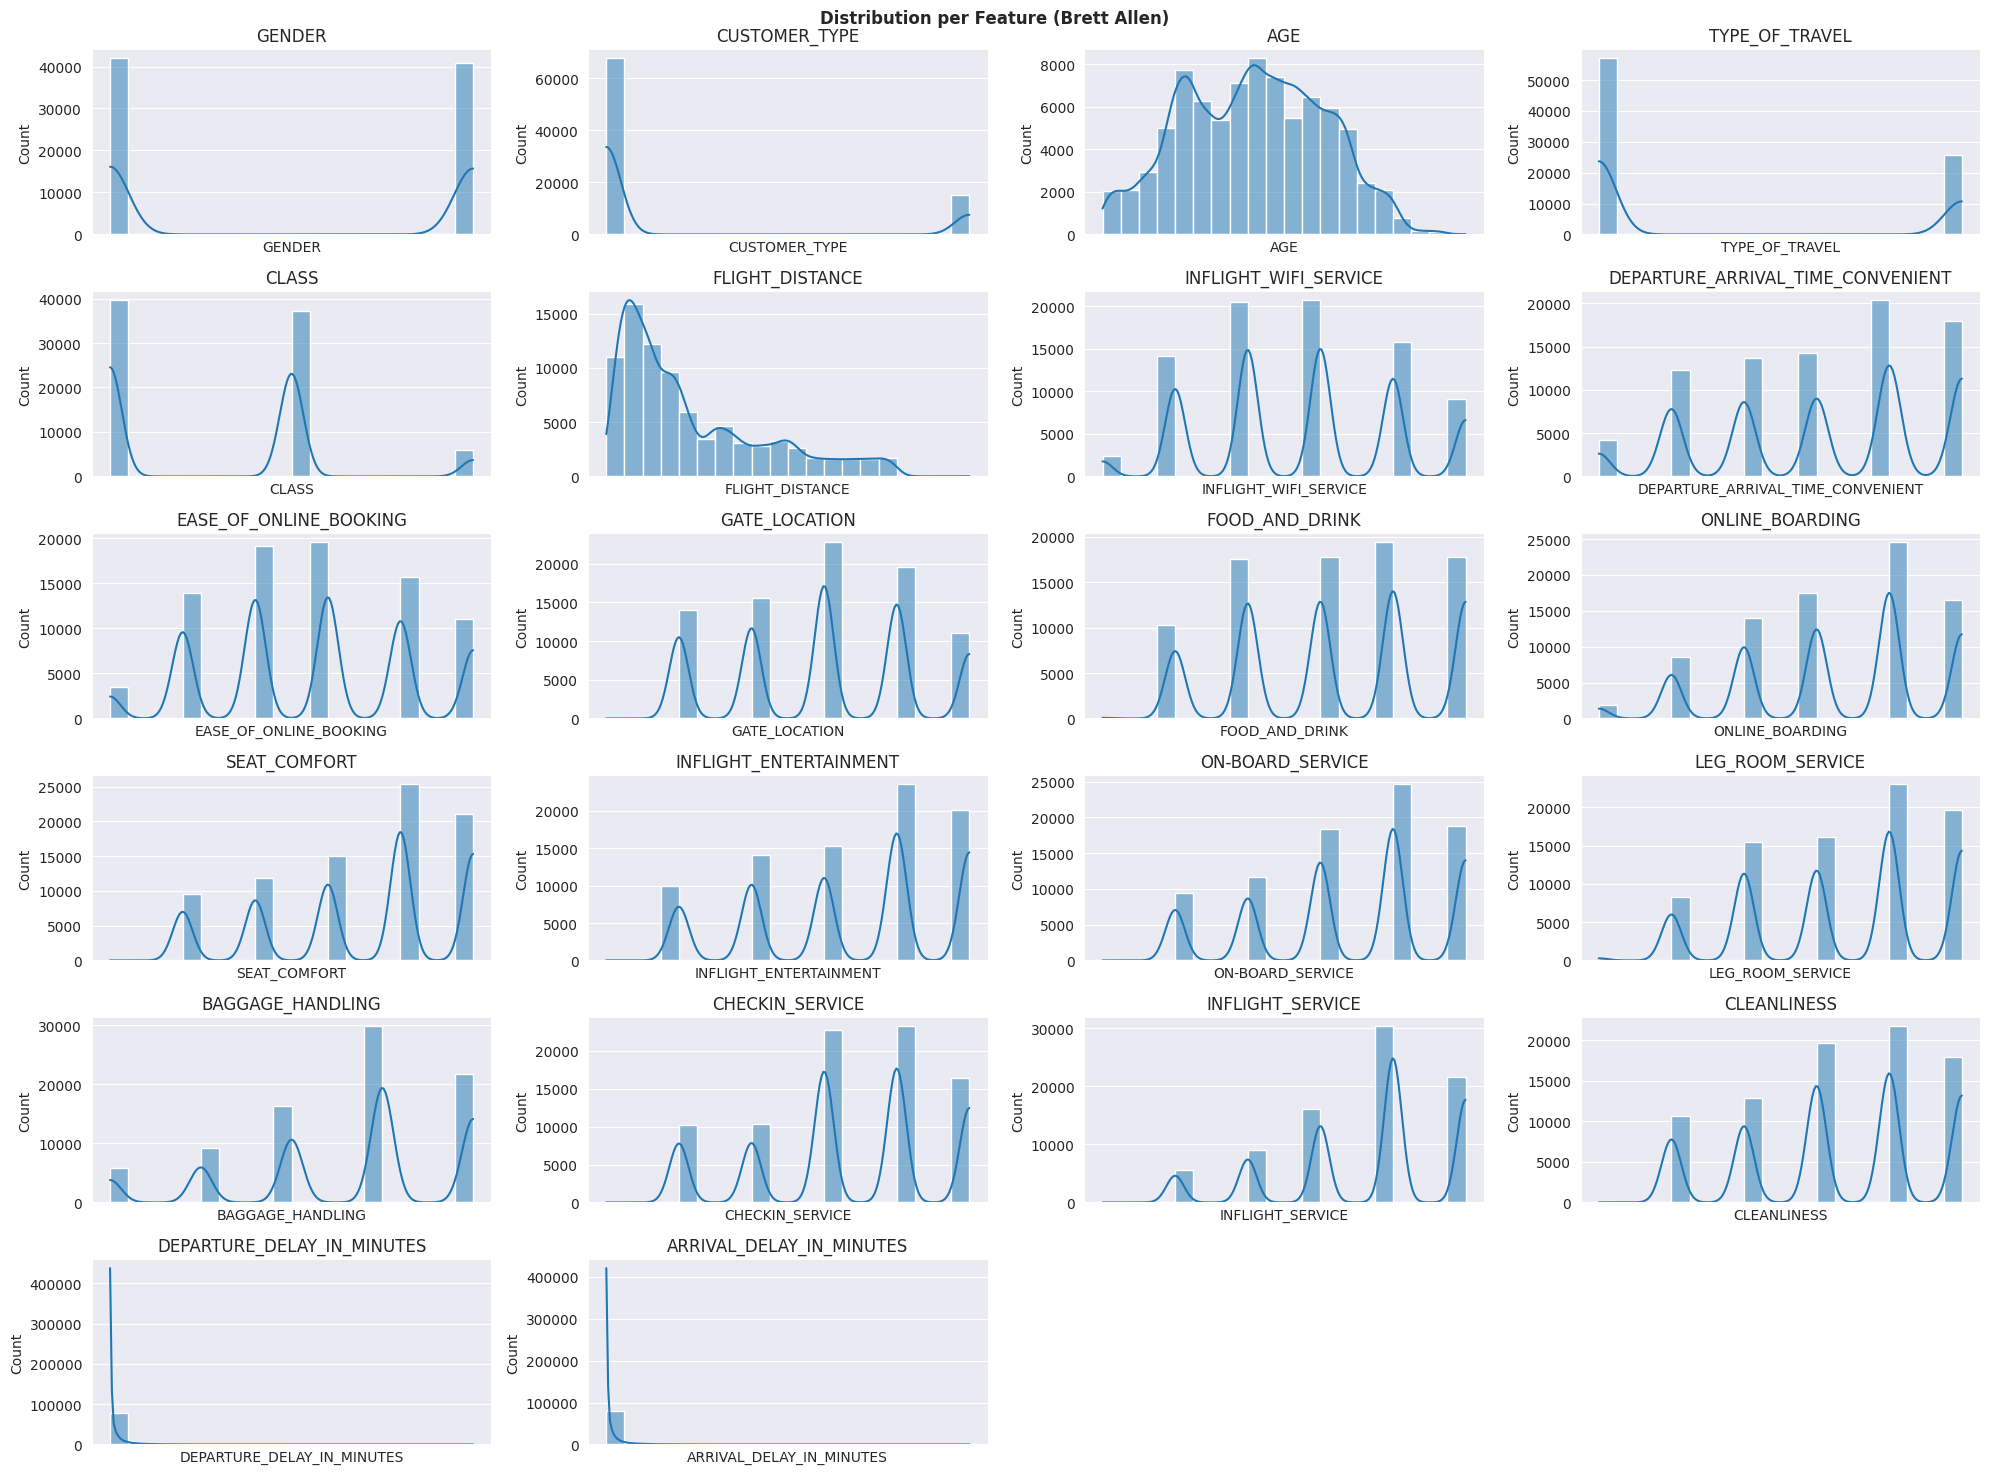

In [34]:
generate_histplots(X_train_standardScaled, kde=True, title='Distribution per Feature (Brett Allen)')

#### Min/Max Scaler

In [35]:
min_max_scaler = MinMaxScaler()
X_train_minMaxScaled = min_max_scaler.fit_transform(X_train)
X_train_minMaxScaled = pd.DataFrame(X_train_minMaxScaled, columns=X_train.columns)

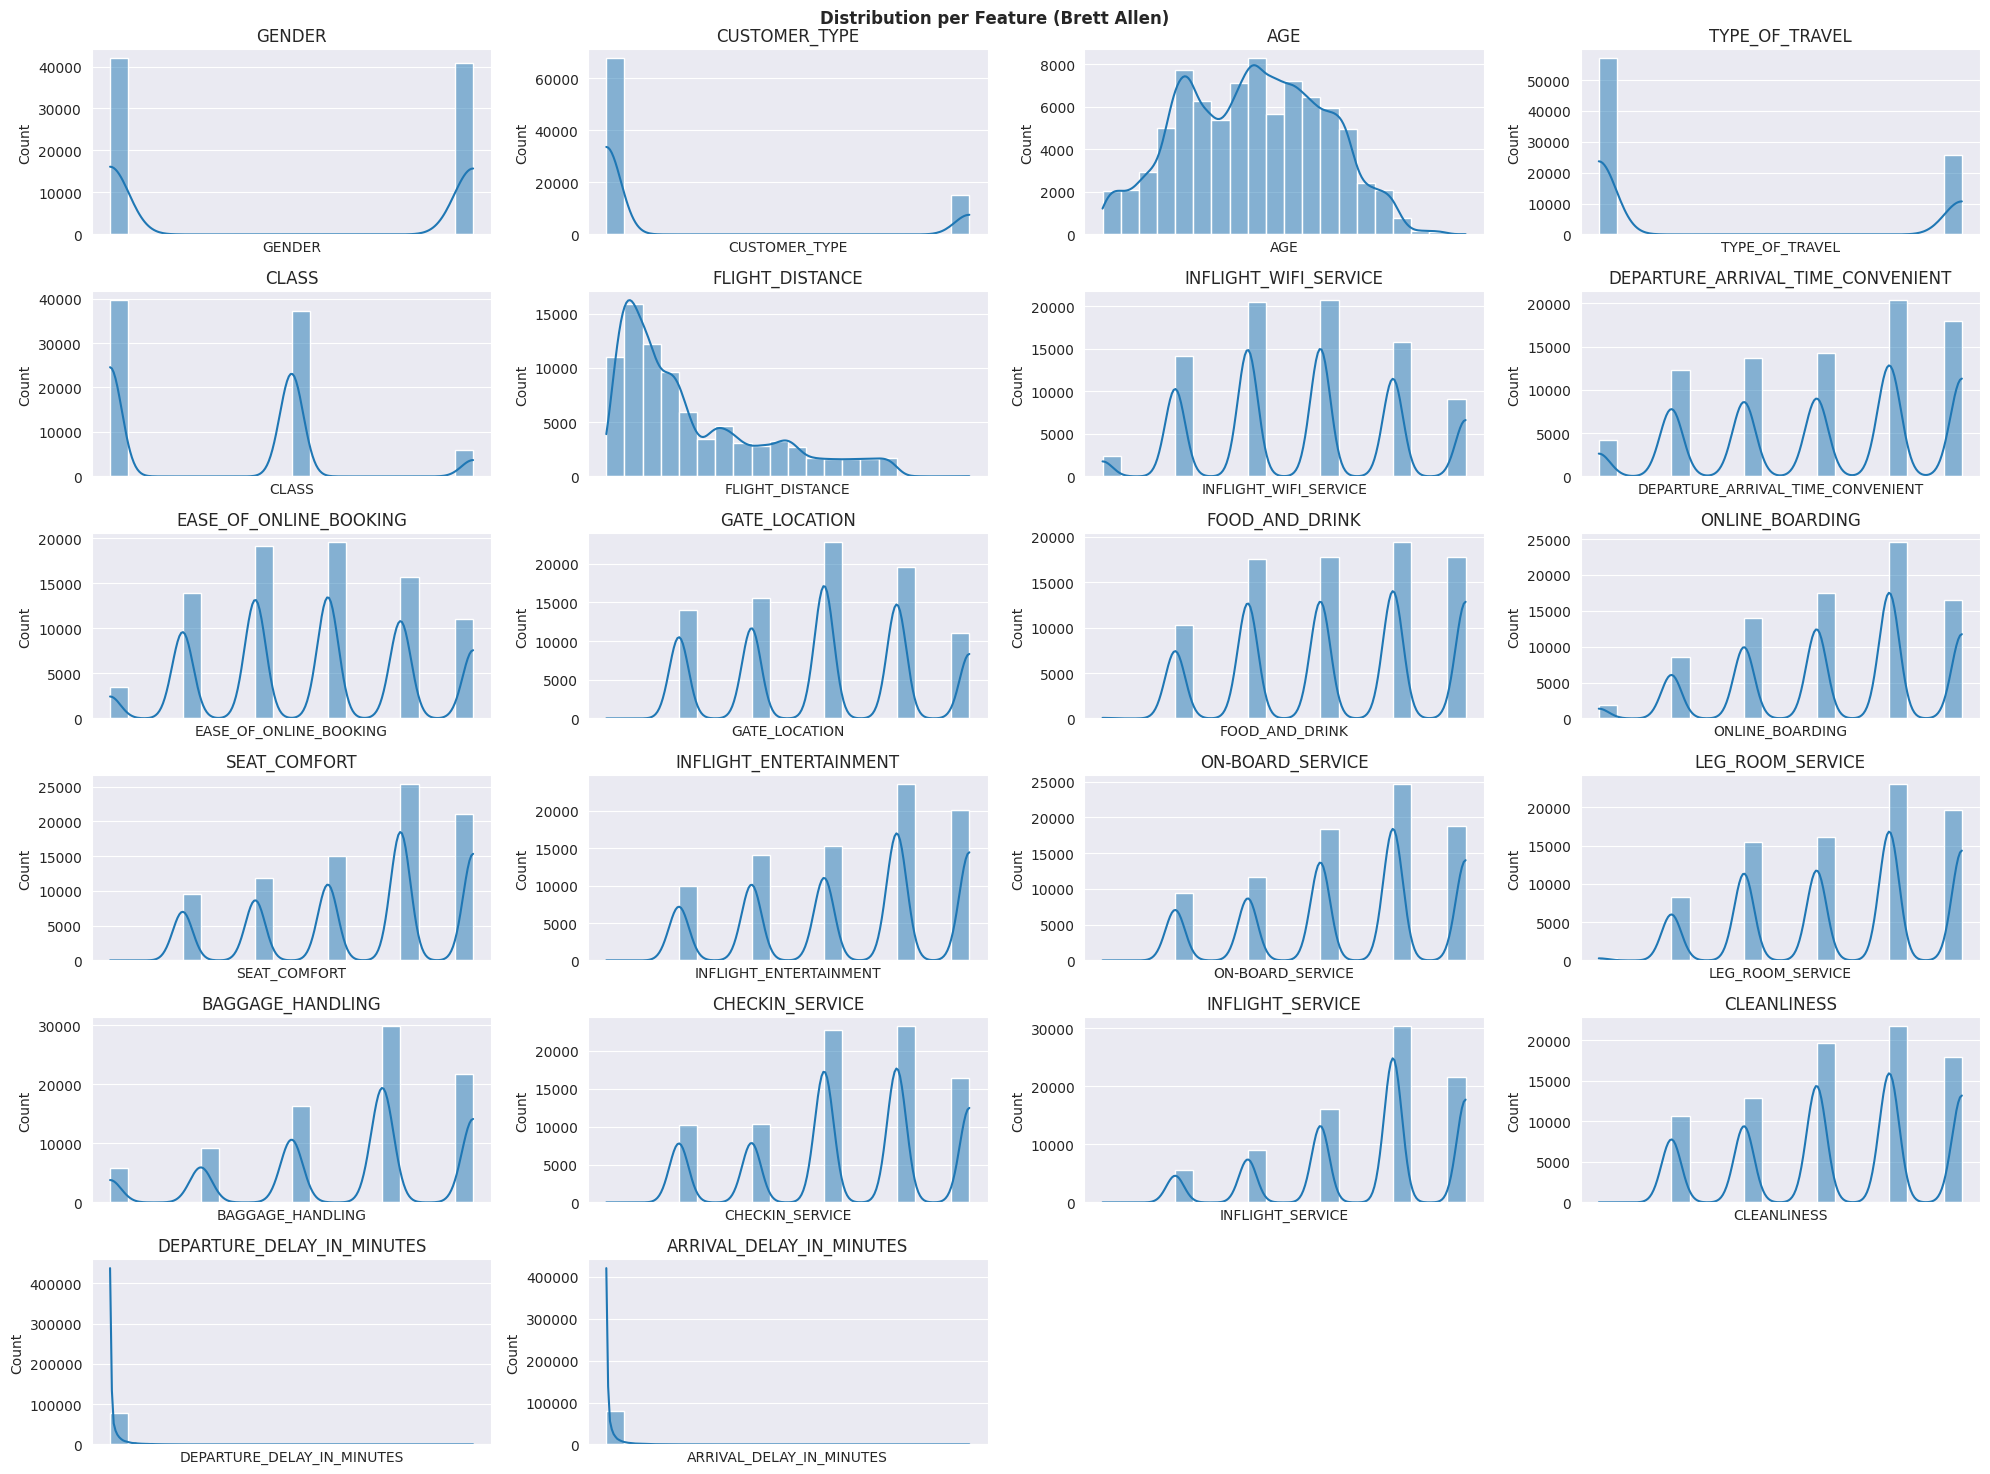

In [36]:
generate_histplots(X_train_minMaxScaled, kde=True, title='Distribution per Feature (Brett Allen)')

#### Quantile Transform

In [37]:
quantile_transform = QuantileTransformer()
X_train_quantileTransformed = quantile_transform.fit_transform(X_train)
X_train_quantileTransformed = pd.DataFrame(X_train_quantileTransformed, columns=X_train.columns)

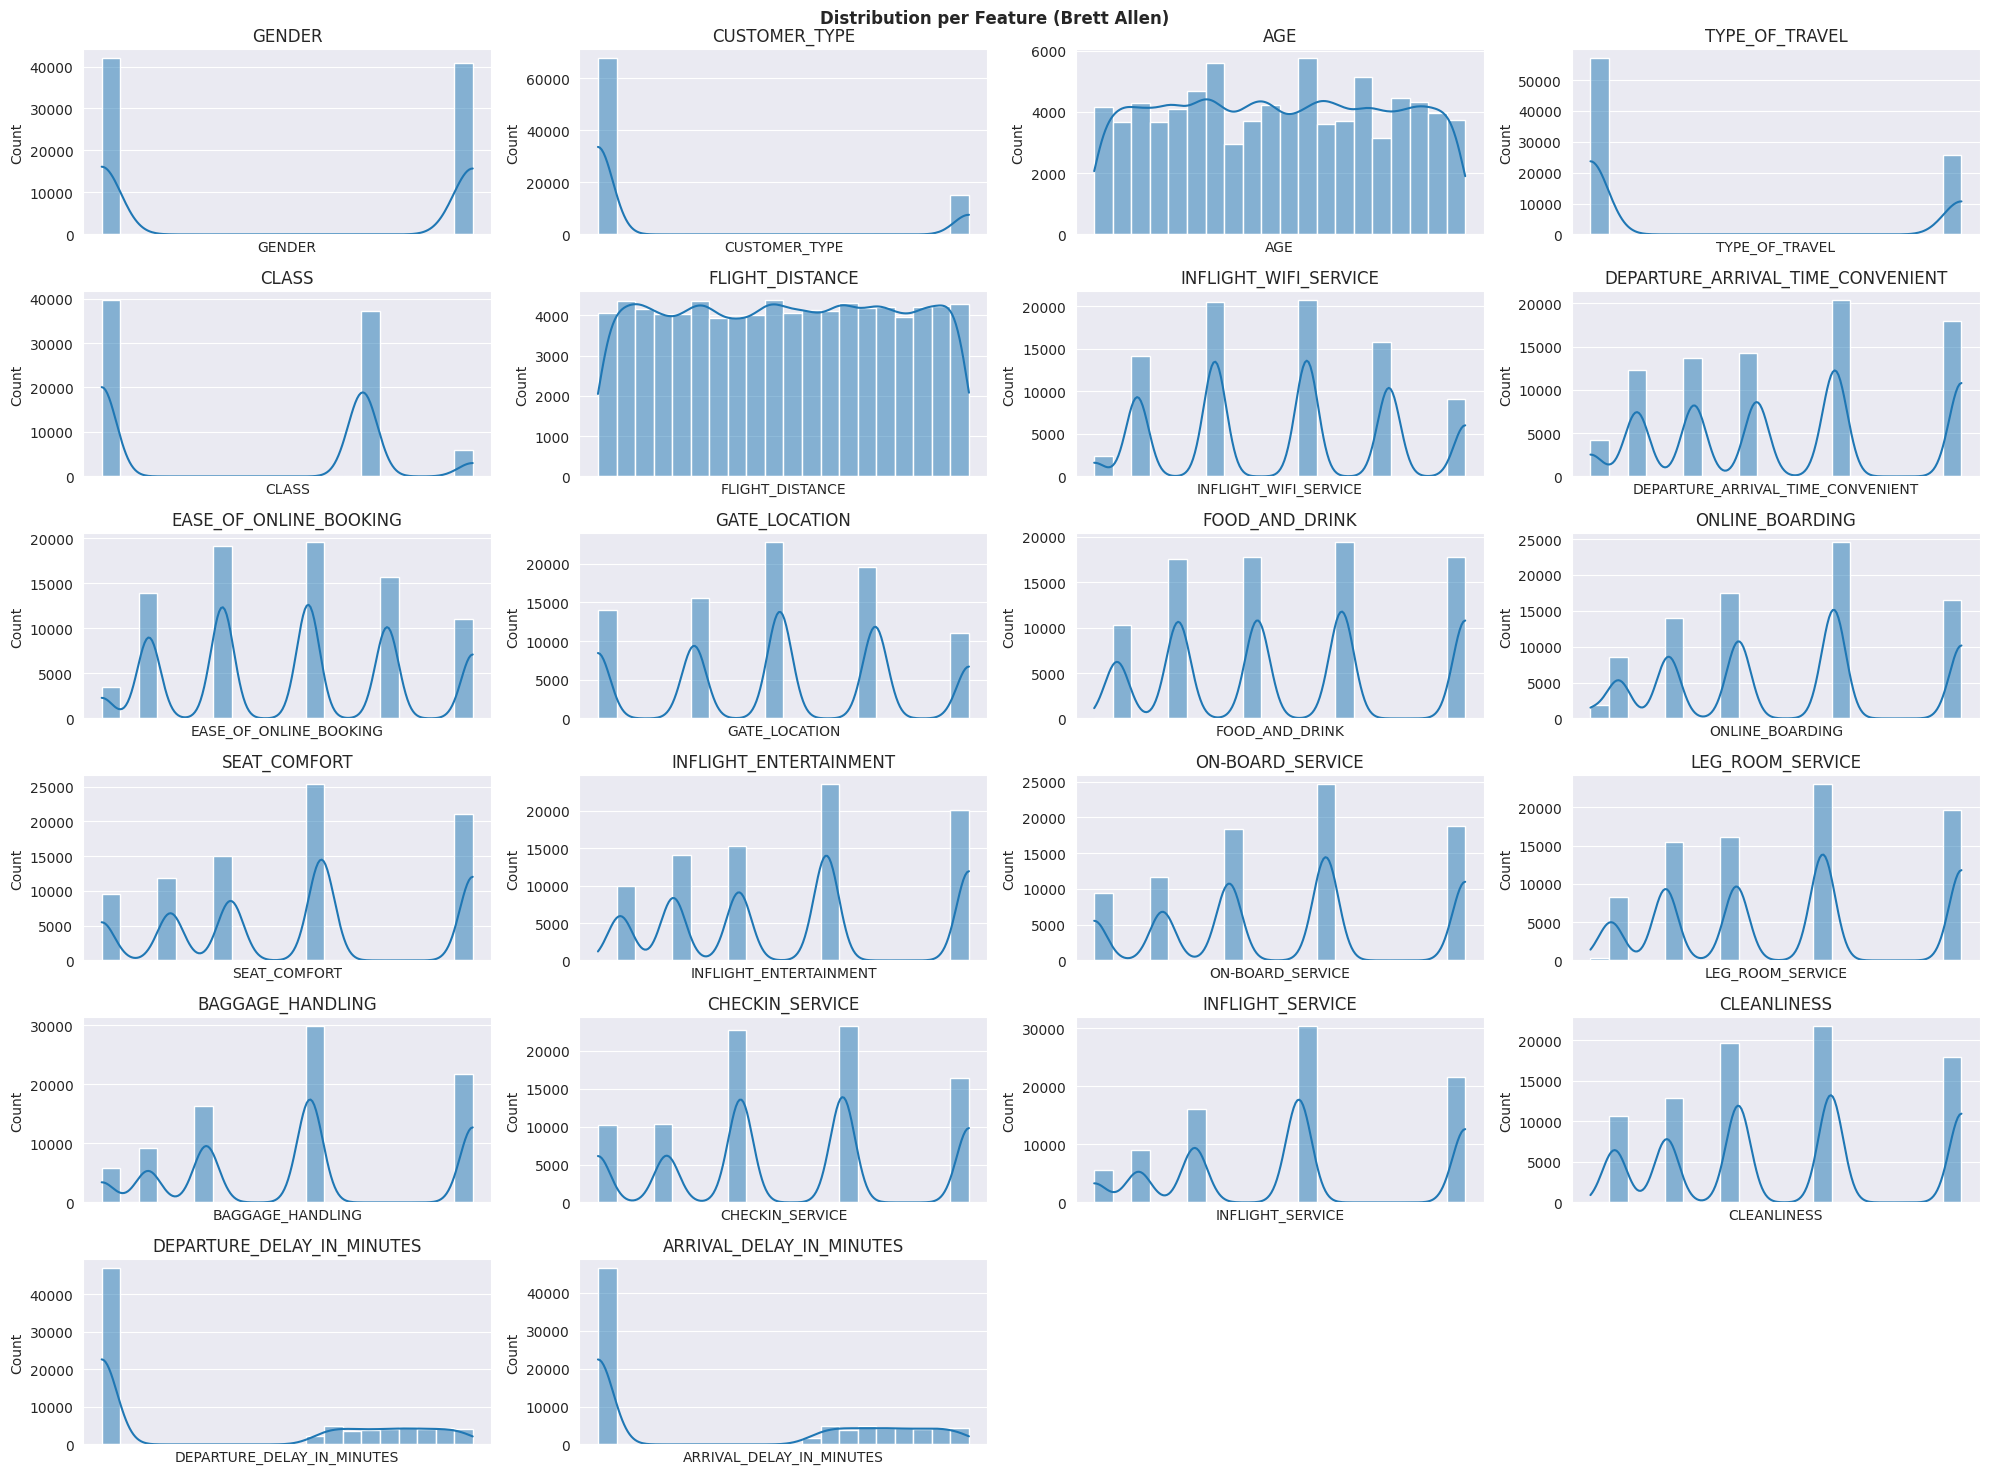

In [38]:
generate_histplots(X_train_quantileTransformed, kde=True, title='Distribution per Feature (Brett Allen)')

#### Log Transform

In [39]:
log_transformer = FunctionTransformer(func=np.log1p)
X_train_logTransformed = log_transformer.fit_transform(X_train)
X_train_logTransformed = pd.DataFrame(X_train_logTransformed, columns=X_train.columns)

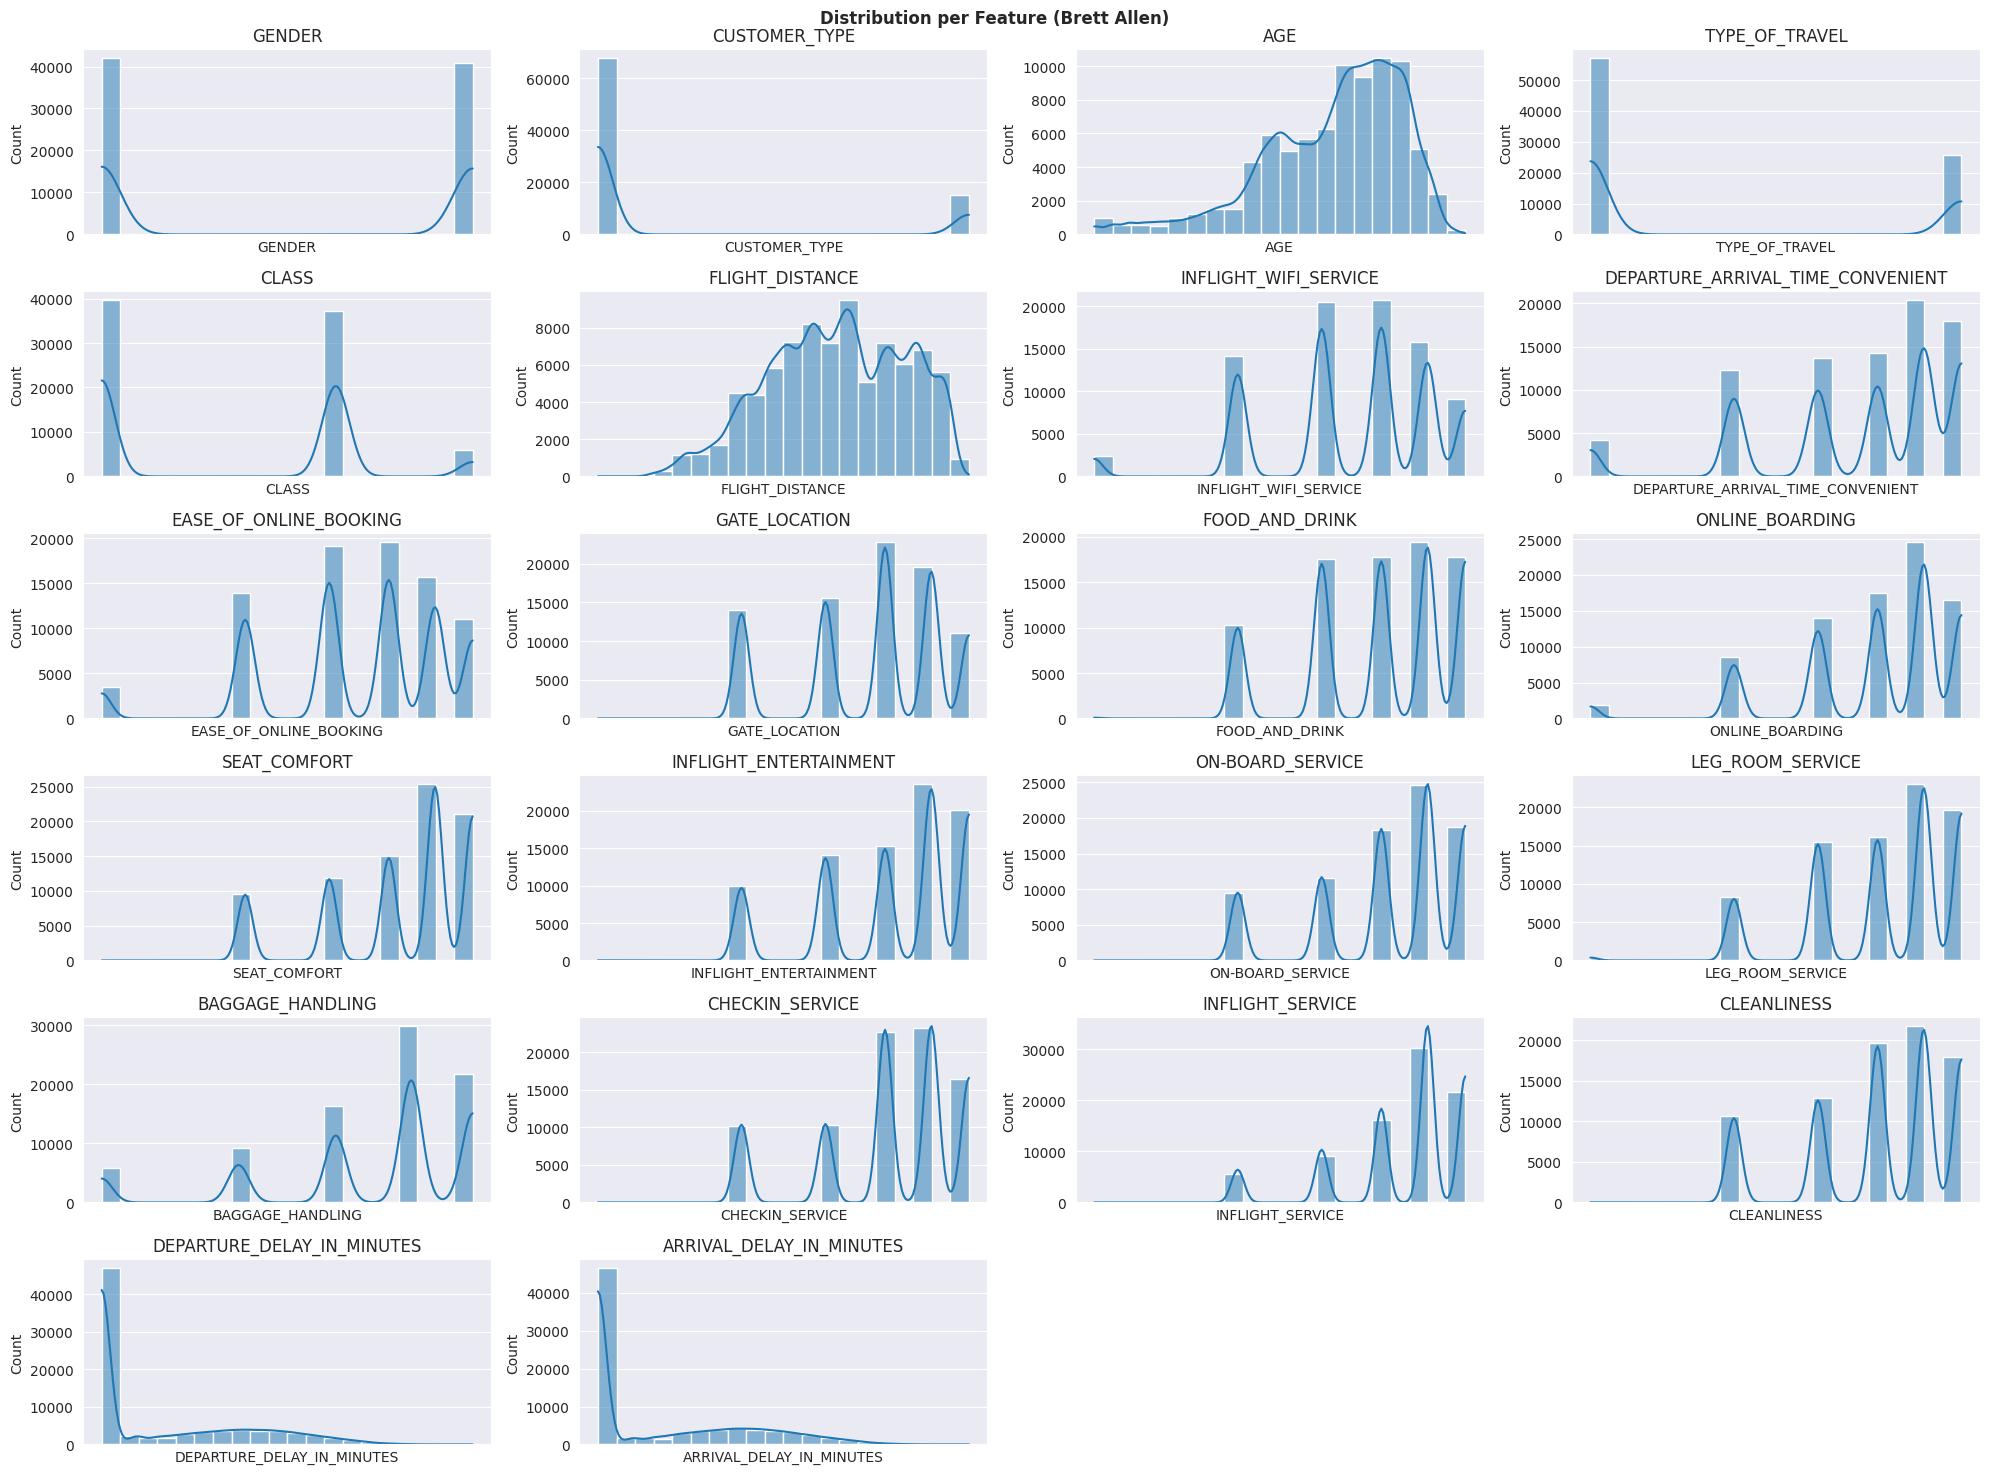

In [40]:
generate_histplots(X_train_logTransformed, kde=True, title='Distribution per Feature (Brett Allen)')

Quantile transform and log transform seem to yield the best results for feature scaling in terms of the resulting distributions of the features. Standard scaler and min/max scaler struggled with arrival and departure delay in minutes features while quantile transform and log transform handled those features better. Thus, will use quantile transform for model training.

## Apply Transformations to Test Data

In [41]:
X_test_standardScaled = standard_scaler.transform(X_test)
X_test_standardScaled = pd.DataFrame(X_test_standardScaled, columns=X_test.columns)

In [42]:
X_test_minMaxScaled = min_max_scaler.transform(X_test)
X_test_minMaxScaled = pd.DataFrame(X_test_minMaxScaled, columns=X_test.columns)

In [43]:
X_test_quantileTransformed = quantile_transform.transform(X_test)
X_test_quantileTransformed = pd.DataFrame(X_test_quantileTransformed, columns=X_test.columns)

In [44]:
# Apply log transform to test data
X_test_logTransformed = log_transformer.transform(X_test)
X_test_logTransformed = pd.DataFrame(X_test_logTransformed, columns=X_test.columns)

## Feature Selection
Use Random Forest classifier to identify most important features and select those features.

In [45]:
# Train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_quantileTransformed, y_train)

# Evaluate the model
accuracy_before = rf.score(X_test_quantileTransformed, y_test)
print(f'Accuracy before feature selection: {accuracy_before:.2f}')

Accuracy before feature selection: 0.96


In [46]:
importances = rf.feature_importances_
feature_names = X_train_quantileTransformed.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

In [47]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print(feature_importance_df)

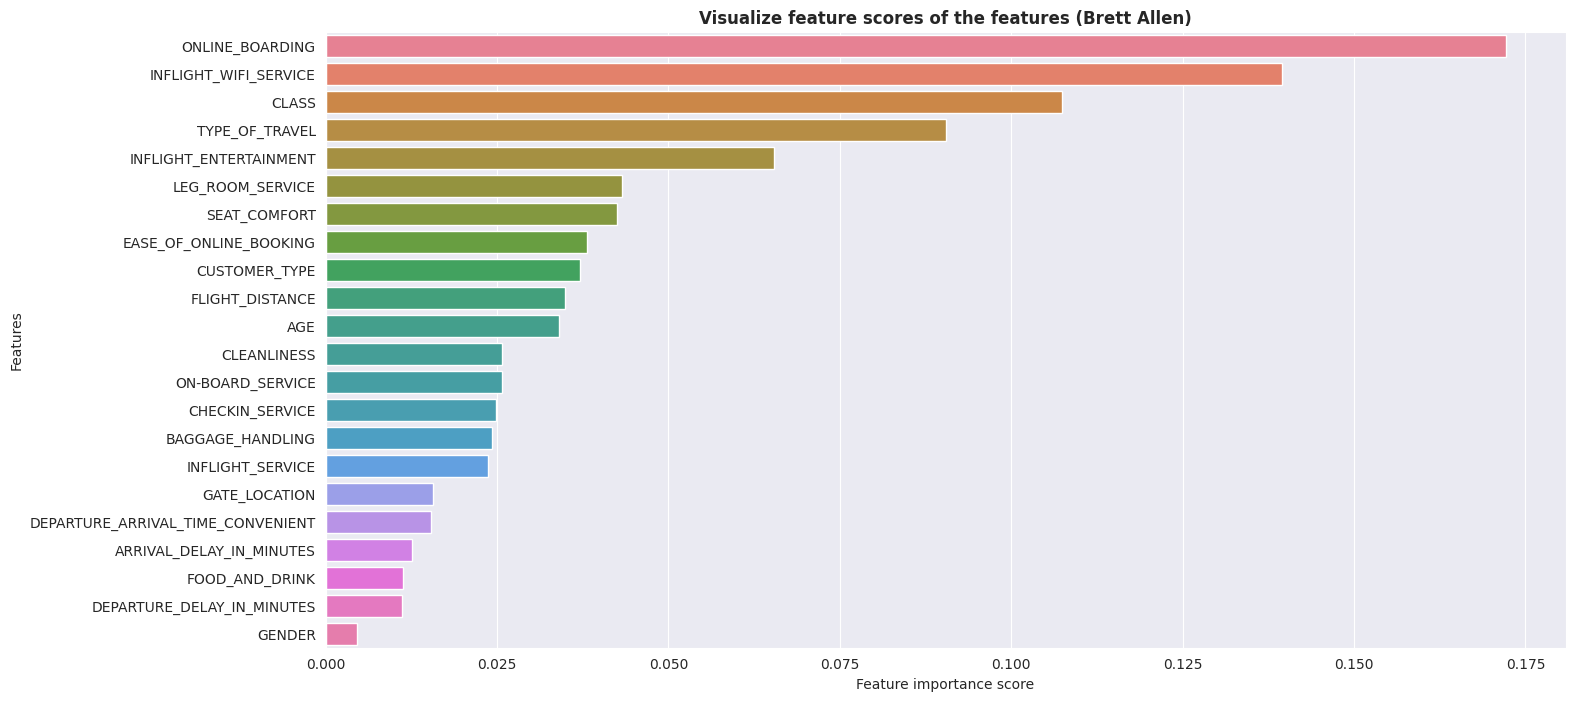

In [48]:
f, ax = plt.subplots(figsize=(16, 8))
ax = sns.barplot(data=feature_importance_df, x='Importance', y='Feature', hue='Feature', legend=False)
ax.set_title("Visualize feature scores of the features (Brett Allen)", weight='bold')
ax.set_xlabel("Feature importance score")
ax.set_ylabel("Features")
plt.show()

## Select and Train Model(s)
Since we are dealing with a binary classification problem, we do not need Softmax regression (which is applicable to multiple classes). Therefore, we will use logistic regression.

### Logistic Regression

In [49]:
logreg_model = LogisticRegression(
    max_iter=1000, 
    C=0.1, 
    penalty="l2",
    random_state=42
)
# logreg_model.fit(X_train_logTransformed, y_train)
logreg_model.fit(X_train_quantileTransformed, y_train)

LogisticRegression(C=0.1, max_iter=1000, random_state=42)

## Evaluate and Fine-Tune Model(s)

### Evaluation

In [50]:
# Compute confusion matrix
def plot_cm(cm, model_name, labels):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.gca().grid(False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

In [51]:
# NOTE: Default threshold = 0.5 for binary classification
def plot_precision_recall_curve(y_true, y_scores, model_name, threshold=0.5):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
    plt.plot(thresholds, recalls[:-1], 'g--', label='Recall', linewidth=2)
    plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label='Threshold')

    # Add intersection points, axis label, legend, and title
    idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
    plt.plot(thresholds[idx], precisions[idx], "bo")
    plt.plot(thresholds[idx], recalls[idx], "go")
    plt.xlabel("Threshold")
    plt.legend(loc="lower left")
    plt.title(f"{model_name} Precision Recall Curve")
    plt.show()

In [52]:
def plot_roc_curve(y_true, y_scores, model_name):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc_score(y_true, y_scores):.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title(f'{model_name} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='best')
    plt.show()

In [53]:
def quick_evaluate(model, test_data, test_labels, model_name, display_labels):
    # Make predictions with the given model
    y_pred = model.predict(test_data)
    y_scores = model.predict_proba(test_data)
    
    # Calculate and print accuraacy on training data
    accuracy = accuracy_score(test_labels, y_pred)
    
    print(f">>> {model_name} accuracy: {accuracy}")
    cm = confusion_matrix(test_labels, y_pred)
    
    # Print classification report for detailed metrics per class
    print("Classification Report:\n", classification_report(test_labels, y_pred))
    
    plot_cm(cm, model_name, display_labels)
    plot_precision_recall_curve(y_test, y_scores[:,-1], model_name)
    plot_roc_curve(y_test, y_scores[:,-1], model_name)

 #### Logistic Regression

>>> Logistic Regression (Brett Allen) accuracy: 0.8822819634152227
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90     11655
           1       0.88      0.84      0.86      9064

    accuracy                           0.88     20719
   macro avg       0.88      0.88      0.88     20719
weighted avg       0.88      0.88      0.88     20719



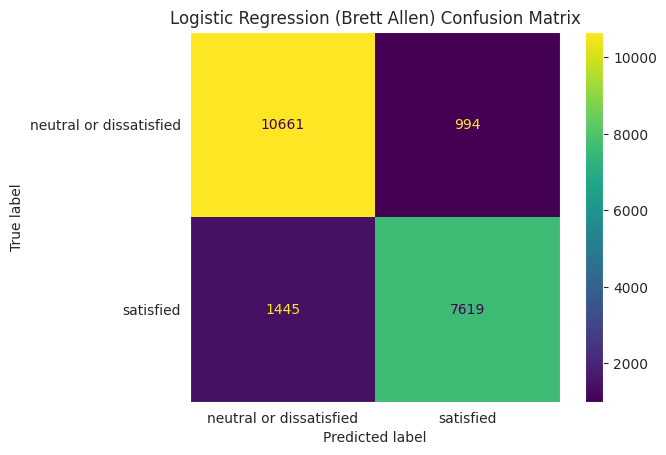

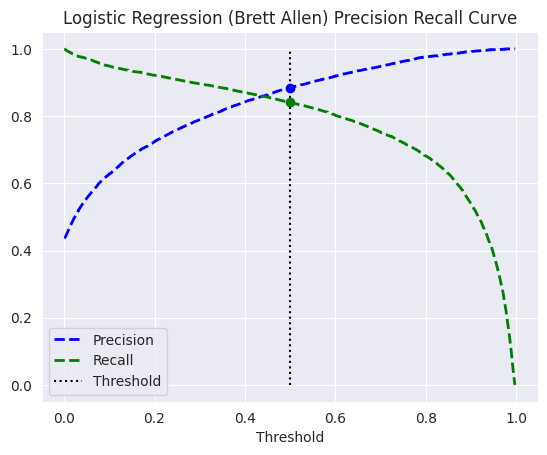

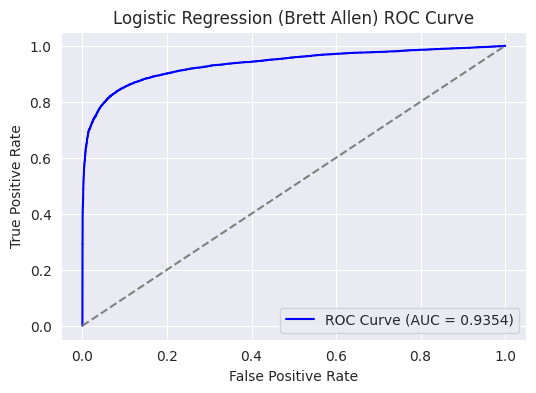

In [54]:
# logreg_model
quick_evaluate(
    model=logreg_model,
    test_data=X_test_quantileTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Logistic Regression (Brett Allen)"
)

### Fine-Tuning

#### Grid Search with Cross Validation

In [55]:
# Define the parameter grid
# ================= ============================== ======================
# solver            penalty                        multinomial multiclass
# ================= ============================== ======================
# 'lbfgs'           'l2', None                     yes
# 'liblinear'       'l1', 'l2'                     no
# 'newton-cg'       'l2', None                     yes
# 'newton-cholesky' 'l2', None                     no
# 'sag'             'l2', None                     yes
# 'saga'            'elasticnet', 'l1', 'l2', None yes
# ================= ============================== ======================
logreg_param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.1, 1, 5, 50, 1000],
    'max_iter': [50, 100, 1000, 10000],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'l1_ratio': [0.1, 0.25, 0.5, 0.75],
    'random_state': [42],
}

# Initialize Logistic Regression model
logreg_model = LogisticRegression()

# Initialize GridSearchCV
grid_search_logreg = GridSearchCV(
    estimator=logreg_model, 
    param_grid=logreg_param_grid, 
    cv=5,
    scoring='accuracy', 
    n_jobs=-1
)

# Perform Grid Search on the training data
grid_search_logreg.fit(X_train_quantileTransformed, y_train)    

# Retrieve the best parameters
best_params_logreg = grid_search_logreg.best_params_
print(f"Best parameters for Logistic Regression with Grid Search: {best_params_logreg}")

Best parameters for Logistic Regression with Grid Search: {'C': 0.1, 'l1_ratio': 0.5, 'max_iter': 50, 'penalty': 'elasticnet', 'random_state': 42, 'solver': 'saga'}


>>> Fine-Tuned Logistic Regression (Grid Search CV) (Brett Allen) accuracy: 0.8822336985375742
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90     11655
           1       0.88      0.84      0.86      9064

    accuracy                           0.88     20719
   macro avg       0.88      0.88      0.88     20719
weighted avg       0.88      0.88      0.88     20719



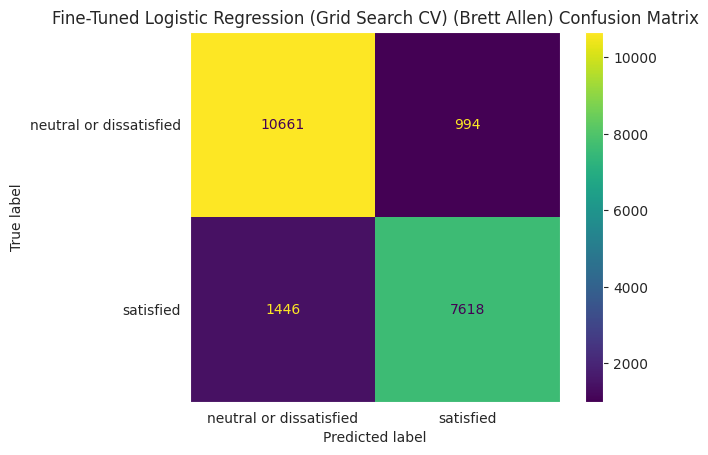

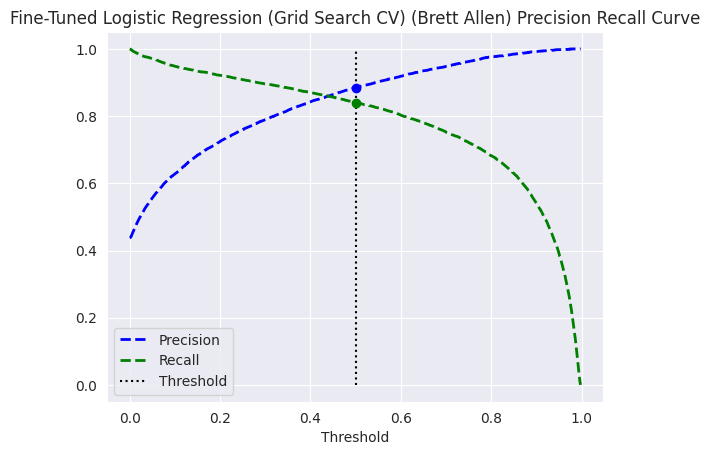

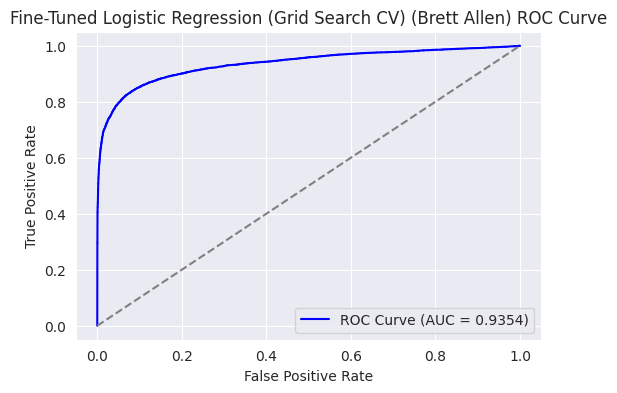

In [56]:
quick_evaluate(
    model=grid_search_logreg.best_estimator_,
    test_data=X_test_quantileTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Fine-Tuned Logistic Regression (Grid Search CV) (Brett Allen)"
)

#### Random Search with Cross Validation

In [57]:
# RandomizedSearchCV
# See page 94 in Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow textbook
logreg_param_rand_search = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': randint(low=1, high=50),
    'max_iter': randint(low=50, high=1000),
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'random_state': [42],
}

rnd_search_logreg = RandomizedSearchCV(
    LogisticRegression(),
    logreg_param_rand_search,
    cv=5,
    scoring='accuracy', 
    n_jobs=-1
)

# Perform Random Search on the training data
rnd_search_logreg.fit(X_train_quantileTransformed, y_train)

# Retrieve the best parameters
best_params_rnd_search_logreg = rnd_search_logreg.best_params_
print(f"Best parameters for Logistic Regression with Random Search: {best_params_rnd_search_logreg}")

Best parameters for Logistic Regression with Random Search: {'C': 3, 'max_iter': 748, 'penalty': 'l2', 'random_state': 42, 'solver': 'saga'}


>>> Fine-Tuned Logistic Regression (Random Search CV) (Brett Allen) accuracy: 0.8821371687822771
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90     11655
           1       0.88      0.84      0.86      9064

    accuracy                           0.88     20719
   macro avg       0.88      0.88      0.88     20719
weighted avg       0.88      0.88      0.88     20719



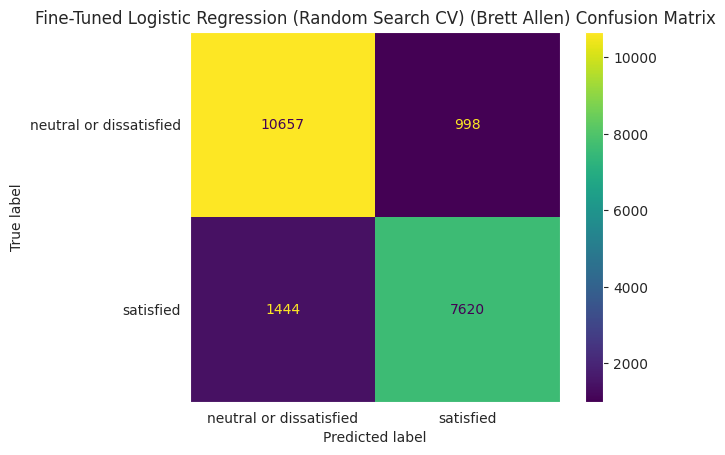

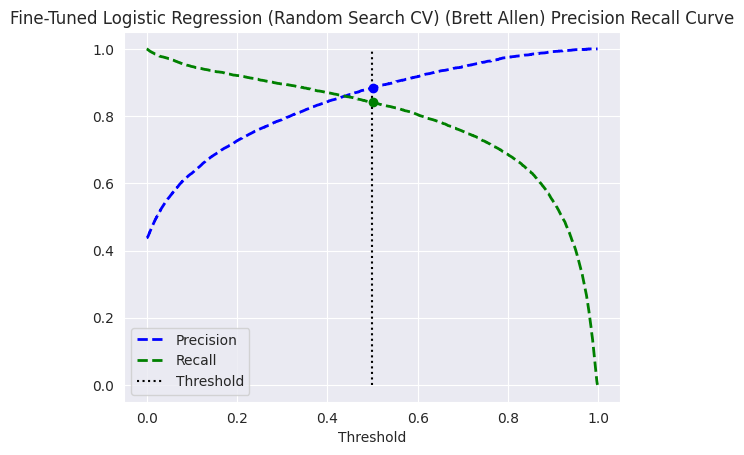

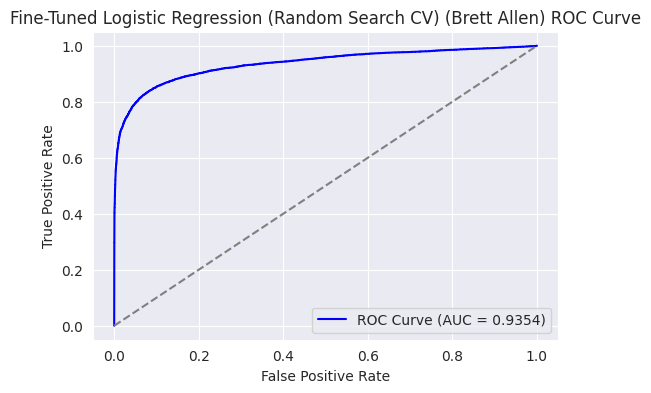

In [58]:
quick_evaluate(
    model=rnd_search_logreg.best_estimator_,
    test_data=X_test_quantileTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Fine-Tuned Logistic Regression (Random Search CV) (Brett Allen)"
)

#### Principal Component Analysis (PCA)

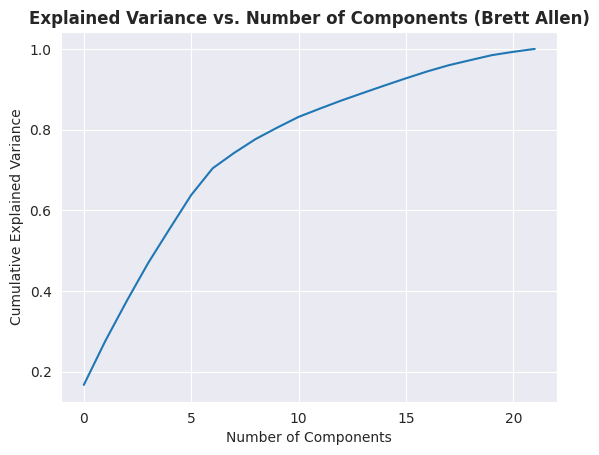

In [59]:
pca = PCA()
pca.fit(X_train_quantileTransformed)

# Calculate the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plot the explained variance ratio
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components (Brett Allen)', weight='bold')
plt.show()

Using the **Elbow Method**, we can see that the optimal number of features is between `15` and `20`, which is where the explained variance starts to level off.

In [60]:
# With threshold method
# Choose the number of components that explain 95% of the variance
threshold = 0.95
n_components = np.argmax(np.cumsum(explained_variance_ratio) >= threshold) + 1
print(f'Using {n_components} principal components will explain {round(threshold*100)}% of the variance')

Using 18 principal components will explain 95% of the variance


Given `18` principal components explains `95%` of the variance in the dataset and this finding is in alignment with the observations from the **Elbow Method** since `18` is between `15` and `20`, we will select `18` as the number of components.

**NOTE** Rather than manually applying a threshold, sklearn PCA supports passing in a threshold as the n_components value. For example `PCA(n_components=0.95)`

In [61]:
# Create a new PCA object with the chosen number of components
pca = PCA(n_components=n_components)

# Fit and transform the data
X_pca = pca.fit_transform(X_train_quantileTransformed)

In [62]:
# logreg_pca_pipeline = Pipeline([
#     ('pca', PCA(n_components=n_components)),
#     ('logreg', LogisticRegression(**best_params_logreg)),
# ])

logreg_pca_pipeline = Pipeline([
    ('pca', PCA(n_components=n_components)),
    ('grid_search_logreg', GridSearchCV(
        estimator=LogisticRegression(),
        param_grid=logreg_param_grid, 
        cv=5,
        scoring='accuracy', 
        n_jobs=-1
    ))
])

logreg_pca_pipeline.fit(X_train_quantileTransformed, y_train)

Pipeline(steps=[('pca', PCA(n_components=np.int64(18))),
                ('grid_search_logreg',
                 GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
                              param_grid={'C': [0.1, 1, 5, 50, 1000],
                                          'l1_ratio': [0.1, 0.25, 0.5, 0.75],
                                          'max_iter': [50, 100, 1000, 10000],
                                          'penalty': ['l1', 'l2', 'elasticnet'],
                                          'random_state': [42],
                                          'solver': ['liblinear', 'lbfgs',
                                                     'saga']},
                              scoring='accuracy'))])

In [63]:
# Retrieve the best parameters
best_params_logreg_pca = logreg_pca_pipeline['grid_search_logreg'].best_params_
print(f"Best parameters for Logistic Regression with PCA and GridSearchCV: {best_params_logreg_pca}")

Best parameters for Logistic Regression with PCA and GridSearchCV: {'C': 1, 'l1_ratio': 0.1, 'max_iter': 50, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs'}


>>> Fine-Tuned Logistic Regression (PCA and Grid Search CV) (Brett Allen) accuracy: 0.8791447463680679
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89     11655
           1       0.88      0.84      0.86      9064

    accuracy                           0.88     20719
   macro avg       0.88      0.87      0.88     20719
weighted avg       0.88      0.88      0.88     20719



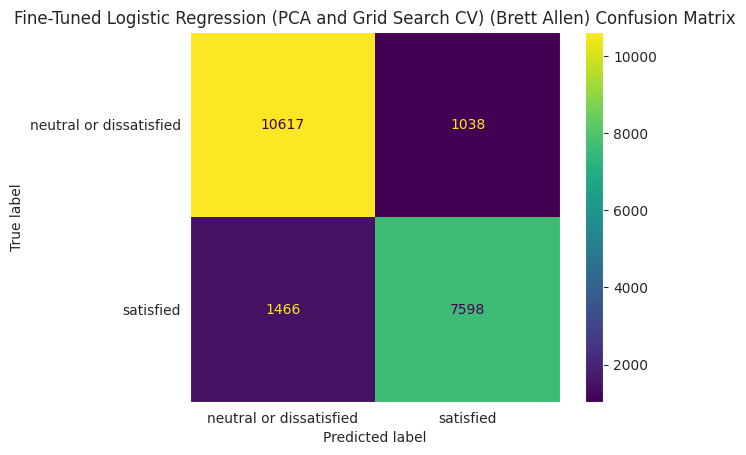

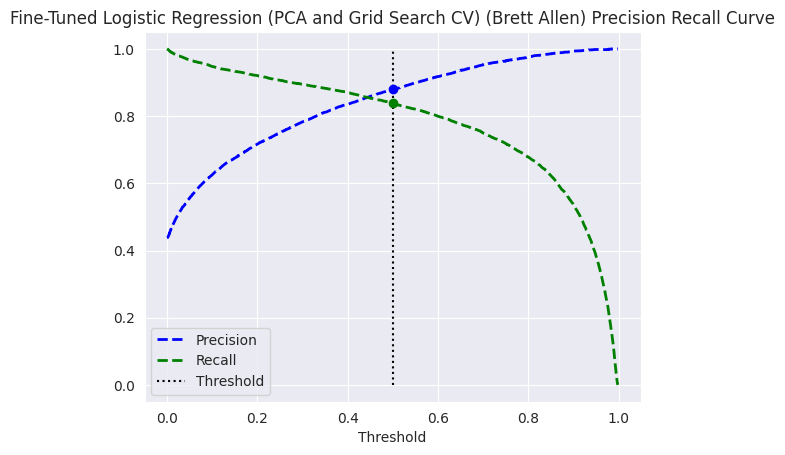

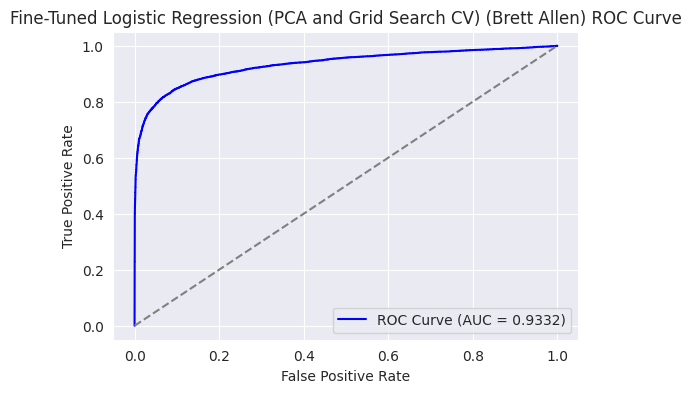

In [64]:
X_test_quantileTransformed_pca = logreg_pca_pipeline['pca'].transform(X_test_quantileTransformed)

# quick_evaluate(
#     model=logreg_pca_pipeline['logreg'],
#     test_data=X_test_quantileTransformed_pca,
#     test_labels=y_test,
#     display_labels=list(label_to_id.keys()),
#     model_name="Fine-Tuned Logistic Regression (Grid Search CV)"
# )
quick_evaluate(
    model=logreg_pca_pipeline['grid_search_logreg'].best_estimator_,
    test_data=X_test_quantileTransformed_pca,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Fine-Tuned Logistic Regression (PCA and Grid Search CV) (Brett Allen)"
)

Using PCA and GridSearchCV does not improve the accuracy of the Logistic Regression model. We could iteratively try a different number of components through grid search but it is unlikely we will see better performance than the results of grid search on all available features.

#### Manual Hyperparameter Tuning

>>> Manual Hyperparameter Tuned Logistic Regression (Brett Allen) accuracy: 0.8822336985375742
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90     11655
           1       0.88      0.84      0.86      9064

    accuracy                           0.88     20719
   macro avg       0.88      0.88      0.88     20719
weighted avg       0.88      0.88      0.88     20719



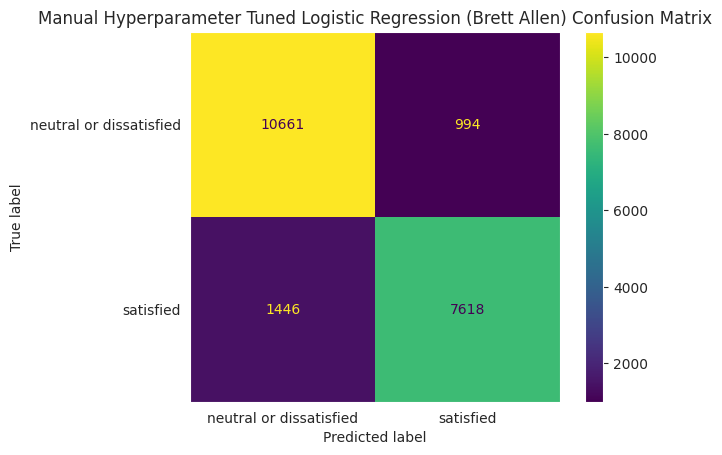

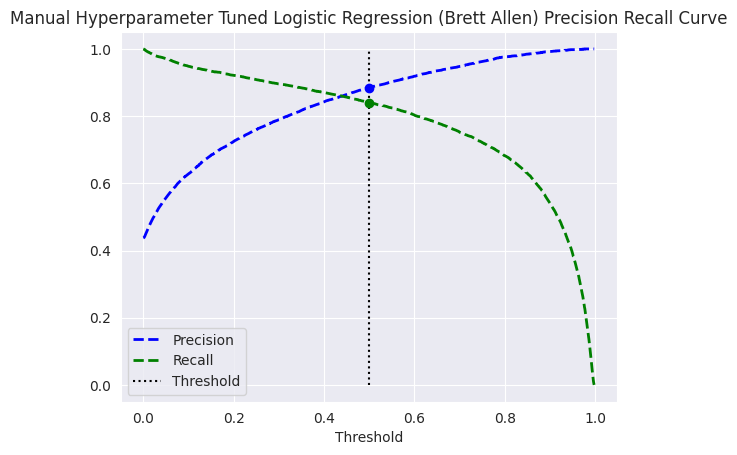

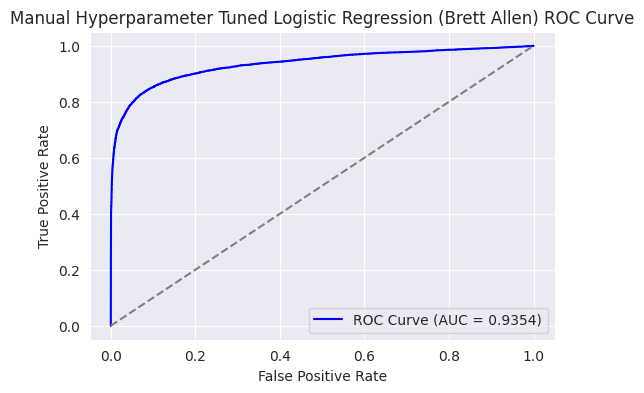

In [65]:
tuned_logreg_model = LogisticRegression(
    max_iter=1000, 
    C=0.1,
    solver='saga',
    penalty="elasticnet",
    l1_ratio=0.5, # equally divide use of l1 and l2 norm using 0.5
    random_state=42
)
tuned_logreg_model.fit(X_train_quantileTransformed, y_train)

quick_evaluate(
    model=tuned_logreg_model,
    test_data=X_test_quantileTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Manual Hyperparameter Tuned Logistic Regression (Brett Allen)"
)

#### UMAP Visualization
Since the performance of the logistic regression model is not being improved with various fine-tuning techniques, it is likely that the data is not adequately linearly separable. We can verify this by using UMAP visualization.

In [66]:
reducer = umap.UMAP()

In [67]:
embedding = reducer.fit_transform(X_train_quantileTransformed)
embedding.shape, X_train_quantileTransformed.shape

((82875, 2), (82875, 22))

We can see there is only two features in the resulting UMAP transformation. This is because UMAP reduces the data to 2D by default. See https://umap-learn.readthedocs.io/en/latest/basic_usage.html

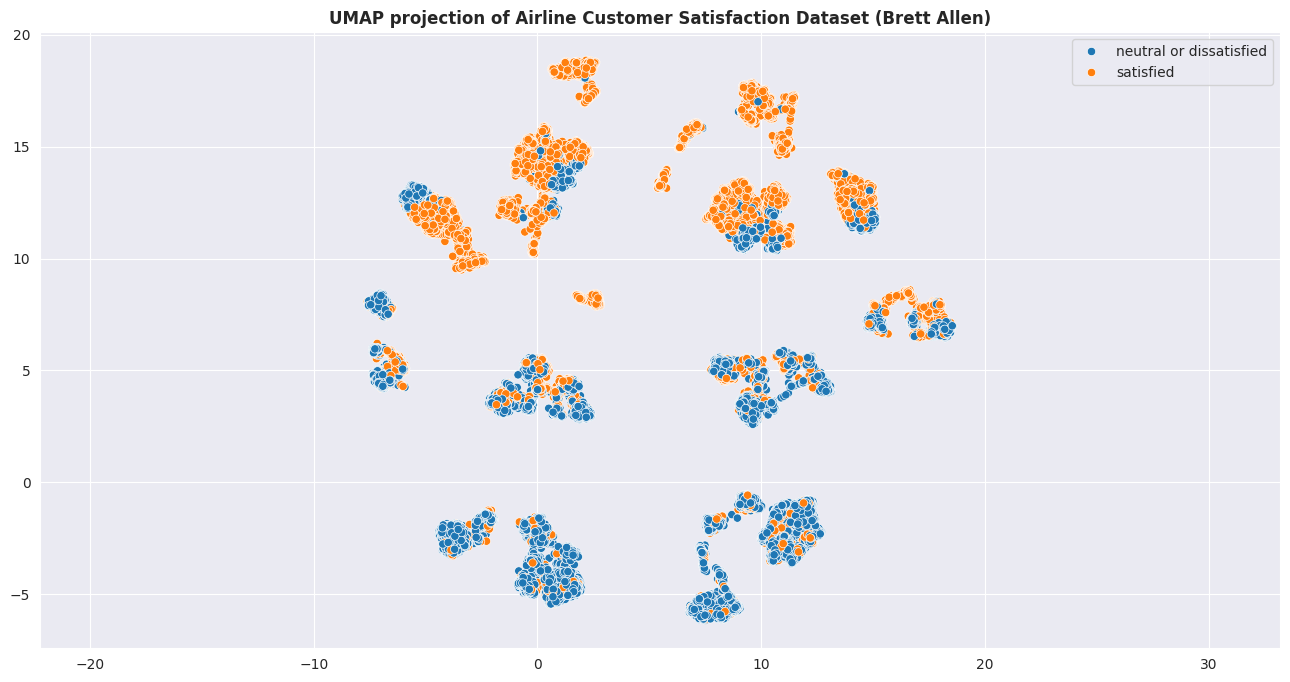

In [68]:
plt.figure(figsize=(16, 8))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y_train.map(id_to_label))
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of Airline Customer Satisfaction Dataset (Brett Allen)', weight='bold')
plt.legend()
plt.show()

We can see based on the UMAP visualization that it is rather challenging to separate the target label in a linear fashion. Many of the clusters are mixed between `neutral or dissatisfied` and `satisfied`. This observation is in alignment with the model performance observed from logistic regression. The model cannot be improved past `88.2%` accuracy because the dataset is not linearly separable enough.

## Conclusion/Insights
After cleaning the data and preparing the data for training, it was evident that log transform and quantile transform held the most promise in terms of normally distributed features. We were able to use a random forest classifier to identify the most important (statistically significant) features, which helped to gain insight on which features have the most influence on the labels. For example, the top 5 most important features were:
1) `ONLINE_BOARDING`
2) `INFLIGHT_WIFI_SERVICE`
3) `CLASS`
4) `TYPE_OF_TRAVEL`
5) `INFLIGHT_ENTERTAINMENT`

After identifying important features, we moved on to training a logistic regression model using quantile transformed data. The base model yielded promising results with approximately `88.2%` accuracy. Various fine-tuning techniques were applied such as grid search, random search, PCA with grid search, and manual hyperparameter tuning with an even distribution of `l1` and `l2` norm via `elasticnet`. Unfortunately, through exhaustive efforts, none of the fine-tuning approaches improved the model accuracy. Through UMAP visualization, we were able to determine that the dataset is not adequately linearly separable for logistic regression. Also, accuracy is not the best metric to use to evaluate logistic regression because the goal of logistic regression is to minimize loss (e.g., RMSE). 

In conclusion, while logistic regression is a good start, ensemble classifiers such as `random forest`, `AdaBoost`, `GradientBoost`, and `XGBoost` perform the best on this dataset. We can see evidence of this with the random forest model used to identify feature importance - the model had an accuracy of `96%` with all features included.